In [1]:
from pathlib import Path
from torchvision import models
import torch.nn as nn
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
import pandas as pd
import json
import timm
from tqdm import tqdm
from torch.optim.lr_scheduler import SequentialLR, LinearLR, CosineAnnealingLR
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
import sys
from pathlib import Path

ROOT = Path.cwd().resolve()
sys.path.append(str(ROOT))

from Utils.project_utils import *
import Utils.constants as c
from Utils.transforms import *
from Utils.MushroomDataset import *
from Utils.dataLoaders import *

In [3]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

print(f"Using device: {device}")

Using device: mps


In [4]:
SPLIT_DIR = Path.cwd().resolve() / "Data" / "splits"

In [5]:
# Load the datasets
train = pd.read_csv(SPLIT_DIR / "train.csv")
val = pd.read_csv(SPLIT_DIR / "val.csv")
test = pd.read_csv(SPLIT_DIR / "test.csv")

In [6]:
# Load the class mapping
with open(SPLIT_DIR / "class_to_idx.json", "r") as f:
    train_class_to_idx = json.load(f)

In [7]:
# Define transforms (fixing the syntax error from before)
train_tfms_mild = get_train_tfms_mild() 
train_tfms_strong = get_train_tfms_strong() 
val_tfms = get_val_tfms()

print("All files loaded successfully!")

All files loaded successfully!


In [8]:
save_dir = PROJECT_ROOT / "Graphs"
save_dir.mkdir(parents=True, exist_ok=True)

In [9]:
CLASSES = sorted(train["class"].unique().tolist())

In [10]:
loaders = make_loaders(
    train,
    val,
    test,
    train_tfms_mild,
    train_tfms_strong,
    val_tfms,
    train_class_to_idx,
    CLASSES,
    c.BATCH_SIZE,
    c.NUM_WORKERS,
    device,
)

loaders

{'train_loader_mild': <torch.utils.data.dataloader.DataLoader at 0x3cf74fc10>,
 'train_loader_strong': <torch.utils.data.dataloader.DataLoader at 0x3cf7d8690>,
 'val_loader': <torch.utils.data.dataloader.DataLoader at 0x3cfaa6bd0>,
 'test_loader': <torch.utils.data.dataloader.DataLoader at 0x3cef74090>}

In [11]:
train_loader = loaders["train_loader_strong"]
val_loader = loaders["val_loader"]
test_loader = loaders["test_loader"]

In [12]:
criterion = nn.CrossEntropyLoss()

## Training and Validation

### Load RESNET50 Model

In [13]:
model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)

In [14]:
model.fc = nn.Linear(model.fc.in_features, len(CLASSES))
model = model.to(device)

optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)

In [15]:
def run_one_epoch(model, loader, criterion, optimizer, device, scaler=None, is_train=False, return_preds=False):
    running_loss = 0.0
    running_correct = 0
    total = 0

    d = device if isinstance(device, torch.device) else torch.device(device)
    use_amp = (d.type == "cuda") and (scaler is not None)

    all_preds, all_labels = [], []

    if is_train:
        model.train()
        for img, labels in loader:
            img = img.to(d, non_blocking=True)
            labels = labels.to(d, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)

            if use_amp:
                with torch.cuda.amp.autocast(True):
                    outputs = model(img)
                    loss = criterion(outputs, labels)
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()
            else:
                outputs = model(img)
                loss = criterion(outputs, labels)
                loss.backward()
                optimizer.step()

            preds = outputs.argmax(1)
            running_loss += loss.item() * img.size(0)
            running_correct += (preds == labels).sum().item()
            total += img.size(0)

            if return_preds:
                all_preds.append(preds.cpu())
                all_labels.append(labels.cpu())
    else:
        model.eval()
        with torch.no_grad():
            for img, labels in loader:
                img = img.to(d, non_blocking=True)
                labels = labels.to(d, non_blocking=True)

                outputs = model(img)
                loss = criterion(outputs, labels)

                preds = outputs.argmax(1)
                running_loss += loss.item() * img.size(0)
                running_correct += (preds == labels).sum().item()
                total += img.size(0)

                if return_preds:
                    all_preds.append(preds.cpu())
                    all_labels.append(labels.cpu())

    total_loss = running_loss / max(total, 1)
    total_acc  = running_correct / max(total, 1)

    if return_preds:
        return total_loss, total_acc, total, torch.cat(all_labels), torch.cat(all_preds)
    else:
        return total_loss, total_acc, total, None, None

In [16]:
BEST_MODEL_PATH = Path.cwd() / "best_models" / "resnet50_best.pth"

In [17]:
BEST_MODEL_PATH.parent.mkdir(parents=True, exist_ok=True)

In [18]:
from tqdm.notebook import tqdm

def run_one_epoch(model, loader, criterion, optimizer, device, scaler=None, is_train=False, return_preds=False):
    running_loss, running_correct, total = 0.0, 0, 0
    all_preds, all_labels = [], []
    
    pbar = tqdm(loader, desc="Training" if is_train else "Validating", leave=False)

    if is_train:
        model.train()
    else:
        model.eval()

    for img, labels in pbar:
        img, labels = img.to(device), labels.to(device)

        if is_train:
            optimizer.zero_grad(set_to_none=True)
            outputs = model(img)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
        else:
            with torch.no_grad():
                outputs = model(img)
                loss = criterion(outputs, labels)

        # update metrics
        preds = outputs.argmax(1)
        running_loss += loss.item() * img.size(0)
        running_correct += (preds == labels).sum().item()
        total += img.size(0)
        
        # 2. update progress bar with live stats
        pbar.set_postfix(loss=f"{loss.item():.4f}", acc=f"{running_correct/total:.4f}")

        if return_preds:
            all_preds.append(preds.cpu())
            all_labels.append(labels.cpu())

    total_loss = running_loss / max(total, 1)
    total_acc = running_correct / max(total, 1)

    return (total_loss, total_acc, total, 
            torch.cat(all_labels) if return_preds else None, 
            torch.cat(all_preds) if return_preds else None)


In [19]:
def train(model, train_loader, val_loader, criterion, optimizer, num_epochs, device, patience=5):
    best_val_acc = -float("inf")
    bad_epochs = 0
    
    epoch_pbar = tqdm(range(num_epochs), desc="Overall Progress")

    for epoch in epoch_pbar:
        # run_one_epoch - show their own bars
        train_loss, train_acc, _, _, _ = run_one_epoch(
            model, train_loader, criterion, optimizer, device, is_train=True
        )
        val_loss, val_acc, _, _, _ = run_one_epoch(
            model, val_loader, criterion, optimizer, device, is_train=False
        )

        # Update the master bar with results
        epoch_pbar.set_description(f"Epoch {epoch+1} | Val Acc: {val_acc:.4f}")

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            bad_epochs = 0
            torch.save(model.state_dict(), BEST_MODEL_PATH)
        else:
            bad_epochs += 1
            if bad_epochs >= patience:
                print(f"\nEarly stopping at epoch {epoch+1}")
                break

    model.load_state_dict(torch.load(BEST_MODEL_PATH, map_location=device))
    return model


In [20]:
trained_model = train(model, train_loader, val_loader, criterion, optimizer, num_epochs=30, device=device, patience=5)

Overall Progress:   0%|          | 0/30 [00:00<?, ?it/s]

Training:   0%|          | 0/151 [00:00<?, ?it/s]

Validating:   0%|          | 0/19 [00:00<?, ?it/s]

Training:   0%|          | 0/151 [00:00<?, ?it/s]

Validating:   0%|          | 0/19 [00:00<?, ?it/s]

...

Training:   0%|          | 0/151 [00:00<?, ?it/s]

Validating:   0%|          | 0/19 [00:00<?, ?it/s]

Training:   0%|          | 0/151 [00:00<?, ?it/s]

Validating:   0%|          | 0/19 [00:00<?, ?it/s]


Early stopping at epoch 26


In [21]:
model.fc = nn.Linear(model.fc.in_features, len(CLASSES))
model = model.to(device)
state_dict = torch.load(BEST_MODEL_PATH, map_location=device)
model.load_state_dict(state_dict)
model.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

## Testing

In [22]:
test_loss, test_acc, test_total, test_labels, test_preds = run_one_epoch(
    model, test_loader, criterion, optimizer, device, is_train=False, return_preds=True
)

Validating:   0%|          | 0/19 [00:00<?, ?it/s]

In [23]:
print("Test accuracy:", test_acc)

Test accuracy: 0.8893502179779946


In [24]:
cm = confusion_matrix(test_labels, test_preds)
print("Confusion matrix:\n", cm)
print("\nClassification report:\n",
    classification_report(test_labels, test_preds, target_names=CLASSES, digits=4))

Confusion matrix:
 [[1446  111   48]
 [ 122 1374  110]
 [  68   74 1464]]

Classification report:
                       precision    recall  f1-score   support

conditionally_edible     0.8839    0.9009    0.8923      1605
              edible     0.8813    0.8555    0.8682      1606
               toxic     0.9026    0.9116    0.9071      1606

            accuracy                         0.8894      4817
           macro avg     0.8893    0.8894    0.8892      4817
        weighted avg     0.8893    0.8894    0.8892      4817



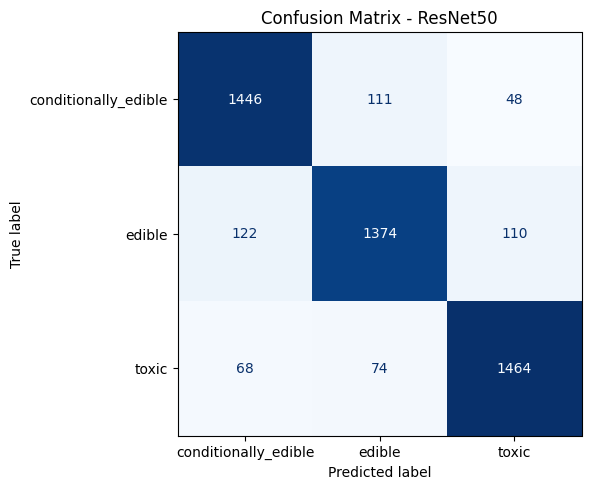

In [25]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASSES)
fig, ax = plt.subplots(figsize=(6,6))
disp.plot(ax=ax, cmap="Blues", colorbar=False)

plt.title("Confusion Matrix - ResNet50")
plt.tight_layout()

# 3. SAVE FIRST, THEN SHOW
plt.savefig(save_dir / "resnet50_confusion_matrix.png", dpi=300)
plt.show()